# EmpaticaE4Stress 테스트 (subject_01 ~ subject_06, ALL Multi-modal)

이 노트북은 CATSA로 학습한 ALL 멀티모달 모델을 EmpaticaE4Stress 데이터에 적용합니다.

라벨 규칙:
- Non-stress(0): 맨 처음 Rest 3분
- Stress(1): Task 1, 2, 3, 4, 5
- 중간/마지막 Rest 구간: 평가에서 제외

참고:
- ACC/EDA/TEMP/HR/HRV를 모두 사용합니다.
- 최종 입력 샘플링레이트는 32Hz로 맞춥니다.
- Task 4는 no time limit이므로, 전체 길이에서 나머지 고정 길이를 빼서 역산합니다.

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

BASE_DIR = Path('/home/binghin2/Myproject')
MODEL_CANDIDATES = [
    BASE_DIR / 'Research' / 'CATSA' / 'Train' / 'Individual_data' / 'ALL' / 'Save_model' / 'ALL_Grand_Final_Production_Model.pt',
    BASE_DIR / 'Research' / 'CATSA' / 'Train' / 'Individual_data' / 'ALL' / 'Save_model' / 'all_1dcnn_transformer_loso_torch_fold_01_Sub1_best.pt',
]
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[0])
DATA_ROOT = BASE_DIR / 'Dataset' / 'EmpaticaE4Stress' / 'Subjects'
SUBJECTS = [f'subject_{i:02d}' for i in range(1, 7)]

ALL_LOSO_PATH = BASE_DIR / 'Research' / 'CATSA' / 'Train' / 'Individual_data' / 'ALL' / 'ALL_LOSO.ipynb'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Model exists: {MODEL_PATH.exists()} -> {MODEL_PATH}')
print(f'ALL_LOSO exists: {ALL_LOSO_PATH.exists()} -> {ALL_LOSO_PATH}')

Device: cuda
Model exists: True -> /home/binghin2/Myproject/Research/CATSA/Train/Individual_data/ALL/Save_model/ALL_Grand_Final_Production_Model.pt
ALL_LOSO exists: True -> /home/binghin2/Myproject/Research/CATSA/Train/Individual_data/ALL/ALL_LOSO.ipynb


In [2]:
import json


def import_symbols_from_notebook(nb_path: Path, symbols: List[str]) -> Dict[str, object]:
    with nb_path.open('r', encoding='utf-8') as f:
        raw_nb = json.load(f)
    code_cells = [c for c in raw_nb.get('cells', []) if c.get('cell_type') == 'code']
    if len(code_cells) == 0:
        raise RuntimeError(f'No code cells found in {nb_path}')

    namespace: Dict[str, object] = {}
    first_source = code_cells[0].get('source', [])
    if isinstance(first_source, list):
        first_source = ''.join(first_source)
    exec(first_source, namespace)

    missing = [name for name in symbols if name not in namespace]
    if missing:
        raise RuntimeError(f'Missing symbols from {nb_path.name}: {missing}')

    return {name: namespace[name] for name in symbols}


symbols = import_symbols_from_notebook(
    ALL_LOSO_PATH,
    symbols=[
        'HyperParameters',
        'MultiModal1DCNNTransformer',
        'bvp_to_hr_hrv_4hz',
        'resample_to_length',
        'FS_ACC',
        'FS_SOURCE_SLOW',
        'FS_SLOW',
    ],
)

HyperParameters = symbols['HyperParameters']
MultiModal1DCNNTransformer = symbols['MultiModal1DCNNTransformer']
bvp_to_hr_hrv_4hz = symbols['bvp_to_hr_hrv_4hz']
resample_to_length = symbols['resample_to_length']
FS_ACC = int(symbols['FS_ACC'])
FS_SOURCE_SLOW = int(symbols['FS_SOURCE_SLOW'])
FS_SLOW = int(symbols['FS_SLOW'])


def load_signal_1d(path: Path) -> np.ndarray:
    df = pd.read_csv(path)
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        vals = df[numeric_cols[0]].to_numpy(dtype=np.float32)
    else:
        vals = pd.to_numeric(df.iloc[:, 0], errors='coerce').to_numpy(dtype=np.float32)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        raise ValueError(f'No valid values in {path}')
    return vals


def load_acc(path: Path) -> np.ndarray:
    vals = pd.read_csv(path).values.astype(np.float32)
    if vals.ndim != 2 or vals.shape[1] < 3:
        raise ValueError(f'ACC must have at least 3 columns: {path}')
    return vals[:, :3]


def build_protocol_labels(total_len: int, fs: int) -> Tuple[np.ndarray, pd.DataFrame, int]:
    fixed_sec = {
        'rest0': 3 * 60,
        'task1': 10 * 60,
        'rest1': 2 * 60,
        'task2': 5 * 60,
        'rest2': 2 * 60,
        'task3': 3 * 60,
        'rest3': 2 * 60,
        'rest4': 2 * 60,
        'task5': 1 * 60,
        'rest5': 2 * 60,
    }
    fixed = {k: int(v * fs) for k, v in fixed_sec.items()}
    fixed_total = sum(fixed.values())
    task4 = max(0, total_len - fixed_total)

    labels = np.full((total_len,), -1, dtype=np.int64)
    rows: List[Tuple[str, int, int, int]] = []

    segments = [
        ('rest0', fixed['rest0'], 0),
        ('task1', fixed['task1'], 1),
        ('rest1', fixed['rest1'], -1),
        ('task2', fixed['task2'], 1),
        ('rest2', fixed['rest2'], -1),
        ('task3', fixed['task3'], 1),
        ('rest3', fixed['rest3'], -1),
        ('task4', task4, 1),
        ('rest4', fixed['rest4'], -1),
        ('task5', fixed['task5'], 1),
        ('rest5', fixed['rest5'], -1),
    ]

    cur = 0
    for name, dur, lab in segments:
        end = min(cur + dur, total_len)
        if end > cur:
            labels[cur:end] = lab
            rows.append((name, cur, end, lab))
        cur = end
        if cur >= total_len:
            break

    seg_df = pd.DataFrame(rows, columns=['segment', 'start_sample', 'end_sample', 'label'])
    seg_df['start_sec'] = seg_df['start_sample'] / fs
    seg_df['end_sec'] = seg_df['end_sample'] / fs
    return labels, seg_df, int(task4 / fs)


def normalize_multimodal(acc: np.ndarray, eda: np.ndarray, temp: np.ndarray, hr: np.ndarray, hrv: np.ndarray, labels: np.ndarray):
    use_mask = labels >= 0
    if np.any(use_mask):
        acc_ref = acc[use_mask]
        eda_ref = eda[use_mask]
        temp_ref = temp[use_mask]
        hr_ref = hr[use_mask]
        hrv_ref = hrv[use_mask]
    else:
        acc_ref, eda_ref, temp_ref, hr_ref, hrv_ref = acc, eda, temp, hr, hrv

    acc_mean = np.mean(acc_ref, axis=0)
    acc_std = np.std(acc_ref, axis=0) + 1e-8
    eda_mean = float(np.mean(eda_ref))
    eda_std = float(np.std(eda_ref)) + 1e-8
    temp_mean = float(np.mean(temp_ref))
    temp_std = float(np.std(temp_ref)) + 1e-8
    hr_mean = float(np.mean(hr_ref))
    hr_std = float(np.std(hr_ref)) + 1e-8
    hrv_mean = float(np.mean(hrv_ref))
    hrv_std = float(np.std(hrv_ref)) + 1e-8

    acc_n = (acc - acc_mean) / acc_std
    eda_n = (eda - eda_mean) / eda_std
    temp_n = (temp - temp_mean) / temp_std
    hr_n = (hr - hr_mean) / hr_std
    hrv_n = (hrv - hrv_mean) / hrv_std
    return acc_n, eda_n, temp_n, hr_n, hrv_n


def build_windows_multimodal(
    acc: np.ndarray,
    eda: np.ndarray,
    temp: np.ndarray,
    hr: np.ndarray,
    hrv: np.ndarray,
    labels: np.ndarray,
    window_size: int,
    stride: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    x_acc_list: List[np.ndarray] = []
    x_slow_list: List[np.ndarray] = []
    y_list: List[int] = []

    n = min(len(acc), len(eda), len(temp), len(hr), len(hrv), len(labels))
    if n < window_size:
        return (
            np.empty((0, 3, window_size), dtype=np.float32),
            np.empty((0, 4, window_size), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
        )

    for i in range(0, n - window_size + 1, stride):
        w_lab = labels[i:i + window_size]
        uniq = np.unique(w_lab)
        if len(uniq) == 1 and uniq[0] in (0, 1):
            w_acc = acc[i:i + window_size]
            w_slow = np.stack([eda[i:i + window_size], temp[i:i + window_size], hr[i:i + window_size], hrv[i:i + window_size]], axis=1)
            x_acc_list.append(w_acc.T.astype(np.float32))
            x_slow_list.append(w_slow.T.astype(np.float32))
            y_list.append(int(uniq[0]))

    if len(y_list) == 0:
        return (
            np.empty((0, 3, window_size), dtype=np.float32),
            np.empty((0, 4, window_size), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
        )

    return (
        np.asarray(x_acc_list, dtype=np.float32),
        np.asarray(x_slow_list, dtype=np.float32),
        np.asarray(y_list, dtype=np.int64),
    )


def prepare_subject_inputs(sub_dir: Path, window_size: int, stride: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    acc = load_acc(sub_dir / 'ACC.csv')
    bvp = load_signal_1d(sub_dir / 'BVP.csv')
    eda = load_signal_1d(sub_dir / 'EDA.csv')
    temp = load_signal_1d(sub_dir / 'TEMP.csv')

    hr_4, hrv_4 = bvp_to_hr_hrv_4hz(bvp, fs=64, out_fs=4)
    low_len = min(len(eda), len(temp), len(hr_4), len(hrv_4))
    target_len = min(len(acc), low_len * (FS_ACC // FS_SOURCE_SLOW))

    if target_len <= 0:
        raise ValueError(f'Invalid aligned length for {sub_dir}')

    acc_part = acc[:target_len]
    eda_32 = resample_to_length(eda[:low_len], target_len)
    temp_32 = resample_to_length(temp[:low_len], target_len)
    hr_32 = resample_to_length(hr_4[:low_len], target_len)
    hrv_32 = resample_to_length(hrv_4[:low_len], target_len)

    labels, _, task4_sec = build_protocol_labels(total_len=target_len, fs=FS_SLOW)
    acc_n, eda_n, temp_n, hr_n, hrv_n = normalize_multimodal(acc_part, eda_32, temp_32, hr_32, hrv_32, labels)

    x_acc, x_slow, y_true = build_windows_multimodal(
        acc_n,
        eda_n,
        temp_n,
        hr_n,
        hrv_n,
        labels,
        window_size=window_size,
        stride=stride,
    )
    return x_acc, x_slow, y_true, task4_sec

In [3]:
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model_state = ckpt['model_state_dict']
    hp_dict = dict(ckpt.get('hyperparameters', {}))
else:
    model_state = ckpt
    hp_dict = {}

hp_dict.setdefault('window_seconds', 60)
hp_dict.setdefault('stride_seconds', 10)
hp_dict.setdefault('transformer_heads', 8)
hp_dict.setdefault('transformer_ff_dim', 192)
hp_dict.setdefault('transformer_layers', 2)
hp_dict.setdefault('dropout_rate', 0.4)
hp_dict.setdefault('transformer_d_model', 48)

hp_fields = getattr(HyperParameters, '__dataclass_fields__', {})
filtered_hp = {k: v for k, v in hp_dict.items() if k in hp_fields}
hp = HyperParameters(**filtered_hp)

WINDOW_SIZE = int(hp.window_seconds) * FS_SLOW
STRIDE = int(hp.stride_seconds) * FS_SLOW

model = MultiModal1DCNNTransformer(hp).to(DEVICE)
model.load_state_dict(model_state)
model.eval()

print('Loaded model checkpoint successfully')
print(f'window_size={WINDOW_SIZE}, stride={STRIDE}, sampling_rate={FS_SLOW}Hz')
if isinstance(ckpt, dict):
    print('Checkpoint keys:', list(ckpt.keys()))

Loaded model checkpoint successfully
window_size=1920, stride=320, sampling_rate=32Hz
Checkpoint keys: ['model_state_dict', 'model_name', 'created_from', 'sampling_rate_hz', 'window_seconds', 'stride_seconds', 'best_epoch', 'best_val_loss', 'device_used_for_training', 'hyperparameters', 'normalization_mode', 'loss_config', 'subject_split', 'history']


/tmp/ipykernel_376291/1397494338.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODEL_PATH, map_location=DEVICE)


In [4]:
rows = []
all_true: List[int] = []
all_pred: List[int] = []

with torch.no_grad():
    for sub in SUBJECTS:
        sub_dir = DATA_ROOT / sub
        try:
            x_acc, x_slow, y_true, task4_sec = prepare_subject_inputs(sub_dir, window_size=WINDOW_SIZE, stride=STRIDE)
        except Exception as e:
            rows.append({
                'subject': sub,
                'n_eval_windows': 0,
                'task4_sec': np.nan,
                'accuracy': np.nan,
                'f1': np.nan,
                'precision': np.nan,
                'recall': np.nan,
                'note': f'Load/prepare error: {e}',
            })
            continue

        if len(y_true) == 0:
            rows.append({
                'subject': sub,
                'n_eval_windows': 0,
                'task4_sec': task4_sec,
                'accuracy': np.nan,
                'f1': np.nan,
                'precision': np.nan,
                'recall': np.nan,
                'note': 'No valid windows after masking',
            })
            continue

        x_acc_t = torch.from_numpy(x_acc).to(DEVICE)
        x_slow_t = torch.from_numpy(x_slow).to(DEVICE)
        logits = model(x_acc_t, x_slow_t)
        y_pred = logits.argmax(dim=1).cpu().numpy().astype(np.int64)

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)

        rows.append({
            'subject': sub,
            'n_eval_windows': int(len(y_true)),
            'task4_sec': task4_sec,
            'accuracy': float(acc),
            'f1': float(f1),
            'precision': float(prec),
            'recall': float(rec),
        })

        all_true.extend(y_true.tolist())
        all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print('=== Per-subject metrics (ALL multimodal) ===')
display(result_df)

if len(all_true) > 0:
    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, zero_division=0)
    overall_prec = precision_score(all_true, all_pred, zero_division=0)
    overall_rec = recall_score(all_true, all_pred, zero_division=0)

    print('\n=== Overall metrics (subject_01~06) ===')
    print(f'Accuracy : {overall_acc:.4f}')
    print(f'F1       : {overall_f1:.4f}')
    print(f'Precision: {overall_prec:.4f}')
    print(f'Recall   : {overall_rec:.4f}')

    cm = confusion_matrix(all_true, all_pred)
    print('\nConfusion Matrix [rows=true, cols=pred]')
    print(cm)

    print('\nClassification Report')
    print(classification_report(all_true, all_pred, target_names=['Non-stress', 'Stress'], zero_division=0))
else:
    print('No aggregated samples to evaluate.')

=== Per-subject metrics (ALL multimodal) ===


,subject,n_eval_windows,task4_sec,accuracy,f1,precision,recall
0,subject_01,159,583,0.553459,0.678733,1.0,0.513699
1,subject_02,144,434,0.583333,0.702970,1.0,0.541985
2,subject_03,75,0,0.786667,0.851852,1.0,0.741935
3,subject_04,106,0,0.698113,0.792208,1.0,0.655914
4,subject_05,117,163,0.897436,0.938776,1.0,0.884615
5,subject_06,68,0,0.573529,0.641975,1.0,0.472727



=== Overall metrics (subject_01~06) ===
Accuracy : 0.6712
F1       : 0.7713
Precision: 1.0000
Recall   : 0.6277

Confusion Matrix [rows=true, cols=pred]
[[ 78   0]
 [220 371]]

Classification Report
              precision    recall  f1-score   support

  Non-stress       0.26      1.00      0.41        78
      Stress       1.00      0.63      0.77       591

    accuracy                           0.67       669
   macro avg       0.63      0.81      0.59       669
weighted avg       0.91      0.67      0.73       669



In [5]:
print(result_df.to_string(index=False))

   subject  n_eval_windows  task4_sec  accuracy       f1  precision   recall
subject_01             159        583  0.553459 0.678733        1.0 0.513699
subject_02             144        434  0.583333 0.702970        1.0 0.541985
subject_03              75          0  0.786667 0.851852        1.0 0.741935
subject_04             106          0  0.698113 0.792208        1.0 0.655914
subject_05             117        163  0.897436 0.938776        1.0 0.884615
subject_06              68          0  0.573529 0.641975        1.0 0.472727


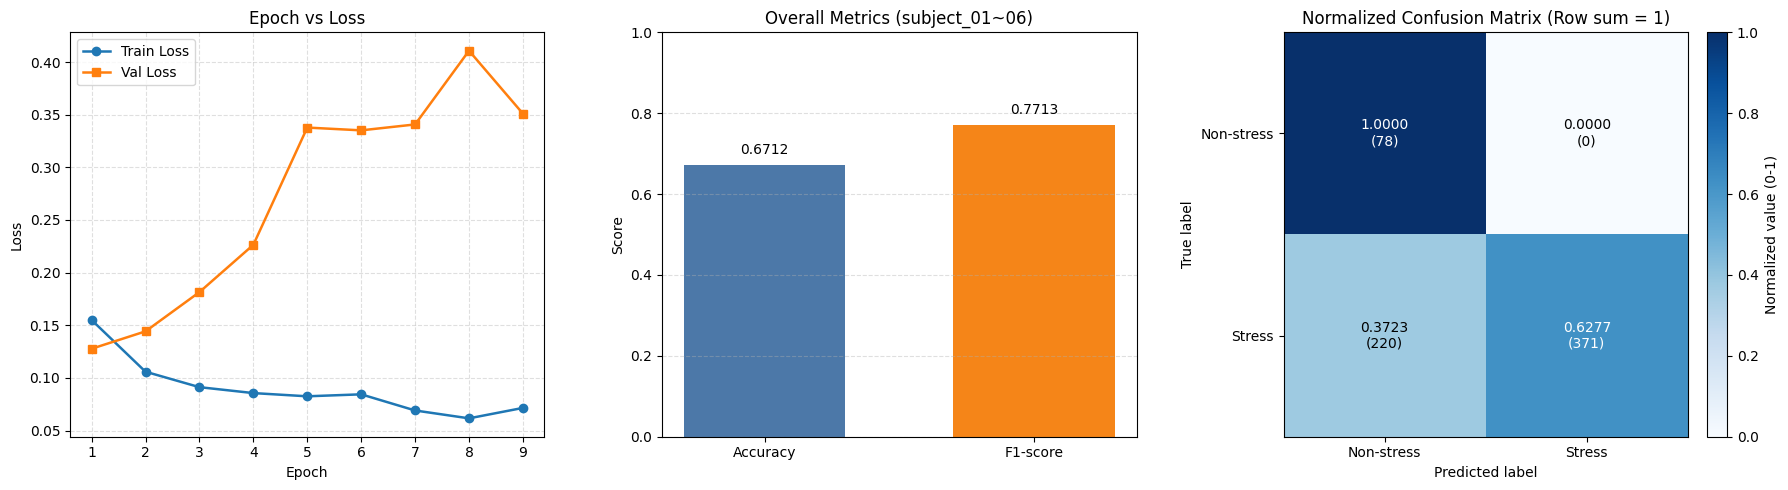

In [6]:
import matplotlib.pyplot as plt

if len(all_true) == 0:
    raise RuntimeError('No aggregated samples to visualize.')

accuracy = accuracy_score(all_true, all_pred)
f1_val = f1_score(all_true, all_pred, zero_division=0)
cm = confusion_matrix(all_true, all_pred)
class_names = ['Non-stress', 'Stress']
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

history = ckpt.get('history', []) if isinstance(ckpt, dict) else []
if history:
    epochs = [int(h.get('epoch', i + 1)) for i, h in enumerate(history)]
    train_loss = [float(h.get('train_loss', np.nan)) for h in history]
    val_loss = [float(h.get('val_loss', np.nan)) for h in history]

    axes[0].plot(epochs, train_loss, marker='o', linewidth=1.8, label='Train Loss')
    axes[0].plot(epochs, val_loss, marker='s', linewidth=1.8, label='Val Loss')
    axes[0].set_title('Epoch vs Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.4)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No history in checkpoint', ha='center', va='center', fontsize=11)
    axes[0].set_title('Epoch vs Loss')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

metrics = ['Accuracy', 'F1-score']
values = [accuracy, f1_val]
colors = ['#4C78A8', '#F58518']
bars = axes[1].bar(metrics, values, color=colors, width=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_title('Overall Metrics (subject_01~06)')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

im = axes[2].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Normalized Confusion Matrix (Row sum = 1)')
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('True label')
axes[2].set_xticks(np.arange(len(class_names)))
axes[2].set_yticks(np.arange(len(class_names)))
axes[2].set_xticklabels(class_names)
axes[2].set_yticklabels(class_names)

threshold = cm_norm.max() / 2 if cm_norm.size else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, f'{cm_norm[i, j]:.4f}\n({cm[i, j]})', ha='center', va='center', color='white' if cm_norm[i, j] > threshold else 'black', fontsize=10)

cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Normalized value (0-1)')

plt.tight_layout()
plt.show()